# Notebook 33 — Controlled ensemble attribution (presentation)

This notebook **only reads** artifacts under
`S4_sbi/results/figure10_8d_7d/notebook_33_ensemble_attribution/`.
It does **not** retrain models, does **not** call the simulator, and must not
launch Phase-2 member-wise PPC during `nbconvert`.

Claim boundary: synthetic cortical-rate proxy diagnostics only. Not real EEG
inversion. `official_300` and `powered_1024` are **descriptive/sensitivity**
datasets only — not an untouched final evaluation split.

In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "S4_sbi").exists() else cwd.parent.parent
RESULTS = PROJECT_ROOT / "S4_sbi" / "results" / "figure10_8d_7d"
N33 = RESULTS / "notebook_33_ensemble_attribution"
assert os.environ.get("CONDA_DEFAULT_ENV") == "neurolib", (
    "Activate conda env neurolib before running notebooks 28–33"
)
assert N33.exists(), f"Missing N33 artifacts: {N33}"
print("environment:", os.environ.get("CONDA_DEFAULT_ENV"))
print("python:", sys.executable)
print("N33:", N33)

environment: neurolib
python: C:\Users\YUS190\AppData\Local\anaconda3\python.exe
N33: D:\Year3_Mao_Projects\sleep_loop\S4_sbi\results\figure10_8d_7d\notebook_33_ensemble_attribution


## 0–1. Purpose, checkpoint audit, protocol lock

In [2]:
gate = json.loads((N33 / "json" / "phase0_gate.json").read_text(encoding="utf-8"))
protocol = json.loads((N33 / "json" / "evaluation_protocol_lock.json").read_text(encoding="utf-8"))
ck = pd.read_csv(N33 / "tables" / "checkpoint_audit.csv")
display(Markdown(
    f"**Phase 0 gate:** `{gate['status']}` — "
    f"checkpoints_ok={gate['checkpoints_ok']} ({gate['checkpoints_n_ok']}/12), "
    f"unit_tests_ok={gate['unit_tests_ok']}, "
    f"official/powered role=`{gate['official_powered_allowed_use']}`, "
    f"untouched_final_evaluation={gate['untouched_final_evaluation']}."
))
display(ck[["track", "scale", "member_index", "seed", "reload_ok", "sample_ok", "theta_dimension"]])

**Phase 0 gate:** `pass` — checkpoints_ok=True (12/12), unit_tests_ok=True, official/powered role=`descriptive_sensitivity_only`, untouched_final_evaluation=False.

,track,scale,member_index,seed,reload_ok,sample_ok,theta_dimension
0,8d,8192,1,9550001,True,True,8
1,7d,8192,1,9551001,True,True,7
2,8d,32768,1,9550001,True,True,8
3,8d,32768,2,9550002,True,True,8
4,8d,32768,3,9550003,True,True,8
5,8d,32768,4,9550004,True,True,8
6,8d,32768,5,9550005,True,True,8
7,7d,32768,1,9551001,True,True,7
8,7d,32768,2,9551002,True,True,7
9,7d,32768,3,9551003,True,True,7


## 2. Evaluation-bank overlap and independence audit

Canonical case hash uses **normalized theta+x only**. Even if overlap is zero,
both banks remain descriptive/sensitivity only. Future member selection or
learned weights require a **new sealed evaluation bank** after freezing rules.

In [3]:
indep = json.loads((N33 / "json" / "evaluation_bank_independence.json").read_text(encoding="utf-8"))
overlap = pd.read_csv(N33 / "tables" / "evaluation_bank_overlap_audit.csv")
scaler = pd.read_csv(N33 / "tables" / "standardizer_fit_source_audit.csv")
display(Markdown(
    f"Policy: official=`{indep['policy']['official_300_role']}`, "
    f"powered=`{indep['policy']['powered_1024_role']}`, "
    f"selection_confirmation_split_allowed=False. "
    f"theta+x disjoint across tracks: **{indep['all_tracks_theta_x_disjoint']}**."
))
display(overlap)
display(scaler)

Policy: official=`descriptive_sensitivity`, powered=`descriptive_sensitivity`, selection_confirmation_split_allowed=False. theta+x disjoint across tracks: **True**.

,track,official_n,powered_n,official_unique_canonical,powered_unique_canonical,exact_theta_x_overlap,theta_only_overlap,x_only_overlap,simulator_seed_overlap,sample_id_overlap_metadata_only,paired_row_id_overlap_metadata_only,overlap_proportion_vs_official,canonical_hash_fields,metadata_fields_excluded_from_canonical_hash,allowed_use_in_notebook_33,untouched_final_evaluation,selection_confirmation_split_allowed,future_selection_requires_sealed_bank,independent_cases_by_theta_x
0,8d,300,1024,300,1024,0,0,0,0,300,300,0.0,"['normalized_theta', 'normalized_x']","['dataset_id', 'sample_id', 'paired_row_id']",descriptive_sensitivity_only,False,False,True,True
1,7d,300,1024,300,1024,0,0,0,0,300,300,0.0,"['normalized_theta', 'normalized_x']","['dataset_id', 'sample_id', 'paired_row_id']",descriptive_sensitivity_only,False,False,True,True


,track,scale,fit_source,train_n,validation_n,train_validation_overlap,location_matches_train_fit,scale_matches_train_fit,evaluation_banks_used_in_fit
0,8d,8192,matched_training_bank_train_ids_only,6553,1639,0,True,True,False
1,8d,32768,matched_training_bank_train_ids_only,26214,6554,0,True,True,False
2,7d,8192,matched_training_bank_train_ids_only,6553,1639,0,True,True,False
3,7d,32768,matched_training_bank_train_ids_only,26214,6554,0,True,True,False


## 3–4. Matched protocol reminder and joint coverage

`powered_1024` results below are **descriptive/sensitivity**, not final sealed evaluation.

,track,estimator,joint_rank_ks_statistic,joint_rank_ks_pvalue,median_normalized_posterior_sd
0,8d,ensemble,0.225012,4.914557e-46,0.635710
1,8d,member_1,0.039950,7.407652e-02,0.632856
2,8d,member_2,0.056158,3.008817e-03,0.633300
3,8d,member_3,0.028643,3.634002e-01,0.589853
4,8d,member_4,0.049738,1.217615e-02,0.641316
5,8d,member_5,0.029275,3.374187e-01,0.644306
8,7d,ensemble,0.211778,8.893435e-41,0.568156
9,7d,member_1,0.046158,2.467063e-02,0.565152
10,7d,member_2,0.030138,3.040273e-01,0.563755
11,7d,member_3,0.033969,1.838677e-01,0.558495


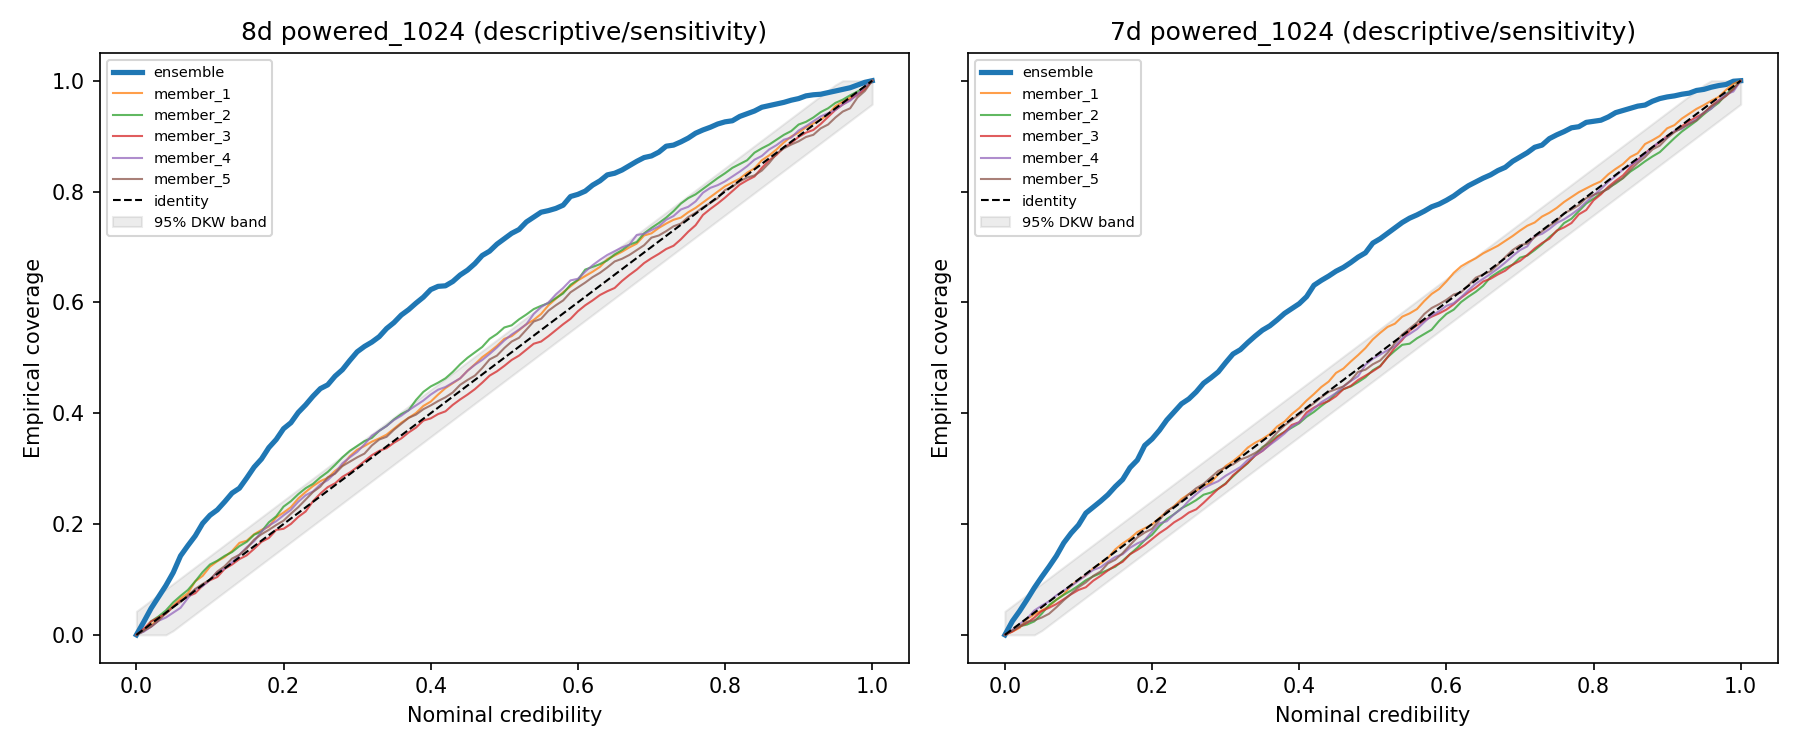

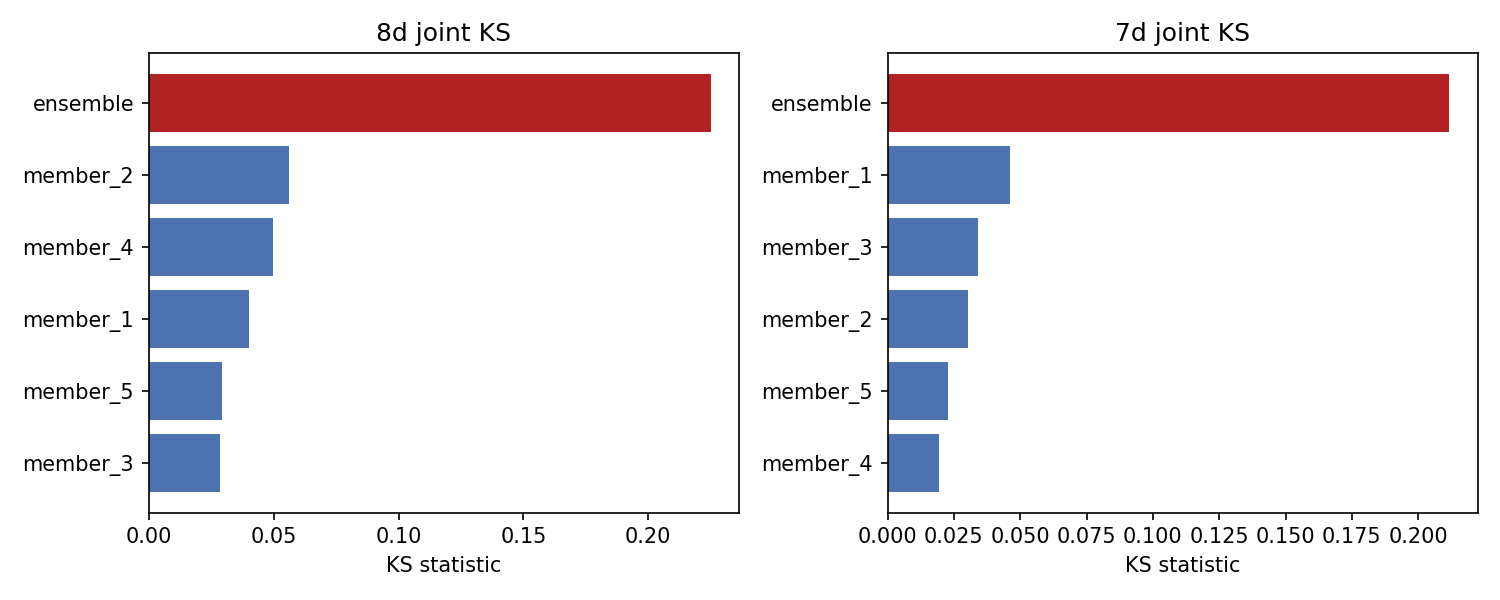

In [4]:
joint = pd.read_csv(N33 / "tables" / "joint_ks_summary.csv")
main = joint[(joint.scale == 32768) & (joint.dataset_role == "descriptive_sensitivity")]
display(main[["track", "estimator", "joint_rank_ks_statistic", "joint_rank_ks_pvalue", "median_normalized_posterior_sd"]])
display(Image(filename=str(N33 / "figures" / "joint_coverage_overlay.png")))
display(Image(filename=str(N33 / "figures" / "joint_ks_ranking.png")))

## 5–7. Marginal SBC, focused parameters, contraction vs recovery

`mui` shows strong contraction with severe SBC mismatch and location shift.
High contraction alone does **not** establish classical overconfidence.
`c_ctx2th` shows weak learning / insufficient constraint under current summaries,
not proven structural non-identifiability.

,track,estimator,parameter,rank_mean,bias_mean,median_norm_sd,calibration_slope
0,8d,ensemble,mue,0.520694,-0.017265,0.553330,0.584674
1,8d,ensemble,mui,0.589638,-0.002453,0.049447,0.996354
3,8d,ensemble,tauA,0.524684,-0.019171,0.725878,0.389078
8,8d,member_1,mue,0.520392,-0.016634,0.539987,0.596990
9,8d,member_1,mui,0.674453,-0.005073,0.051490,0.995108
11,8d,member_1,tauA,0.525211,-0.022253,0.700333,0.378719
16,8d,member_2,mue,0.516846,-0.013236,0.549149,0.601328
17,8d,member_2,mui,0.658479,-0.004186,0.038550,0.997968
19,8d,member_2,tauA,0.522026,-0.016584,0.724375,0.375339
24,8d,member_3,mue,0.512724,-0.007781,0.569415,0.570474


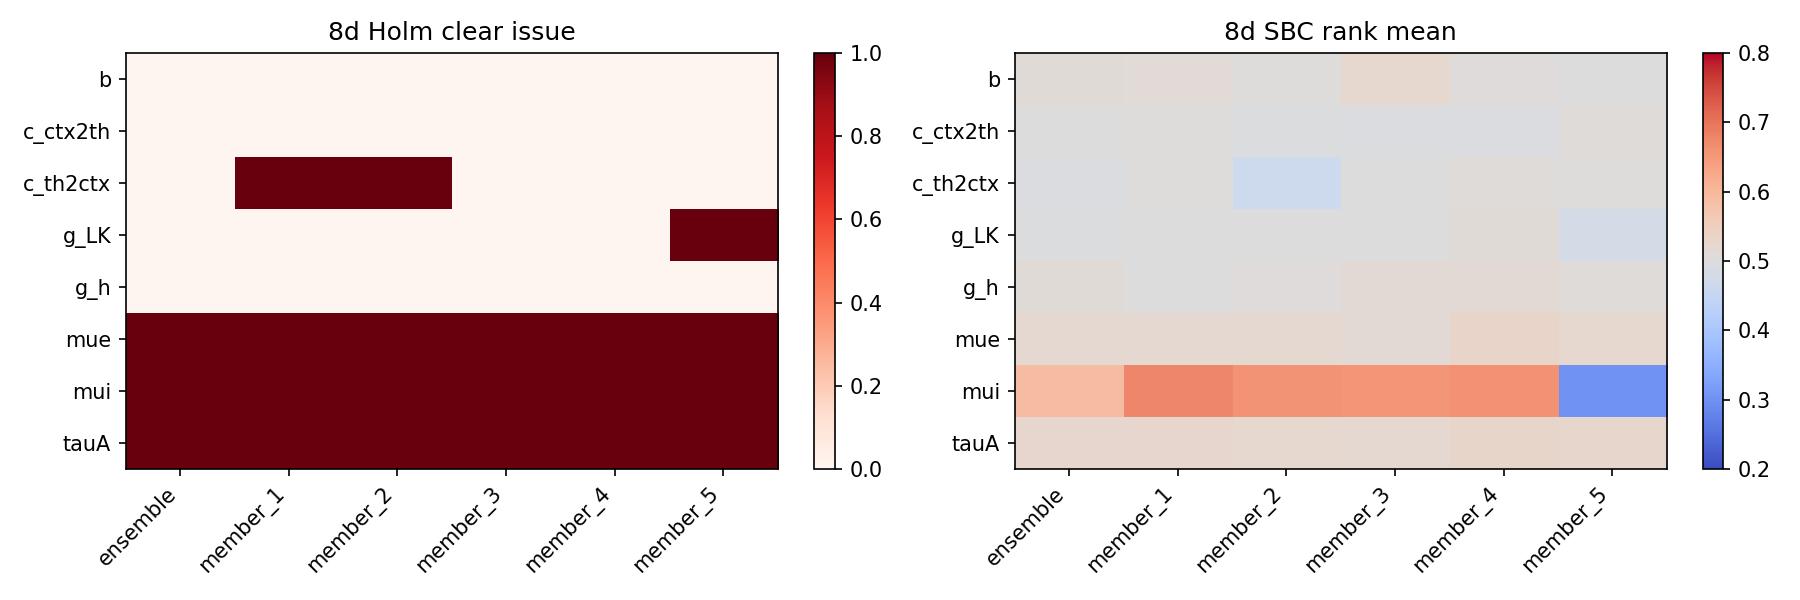

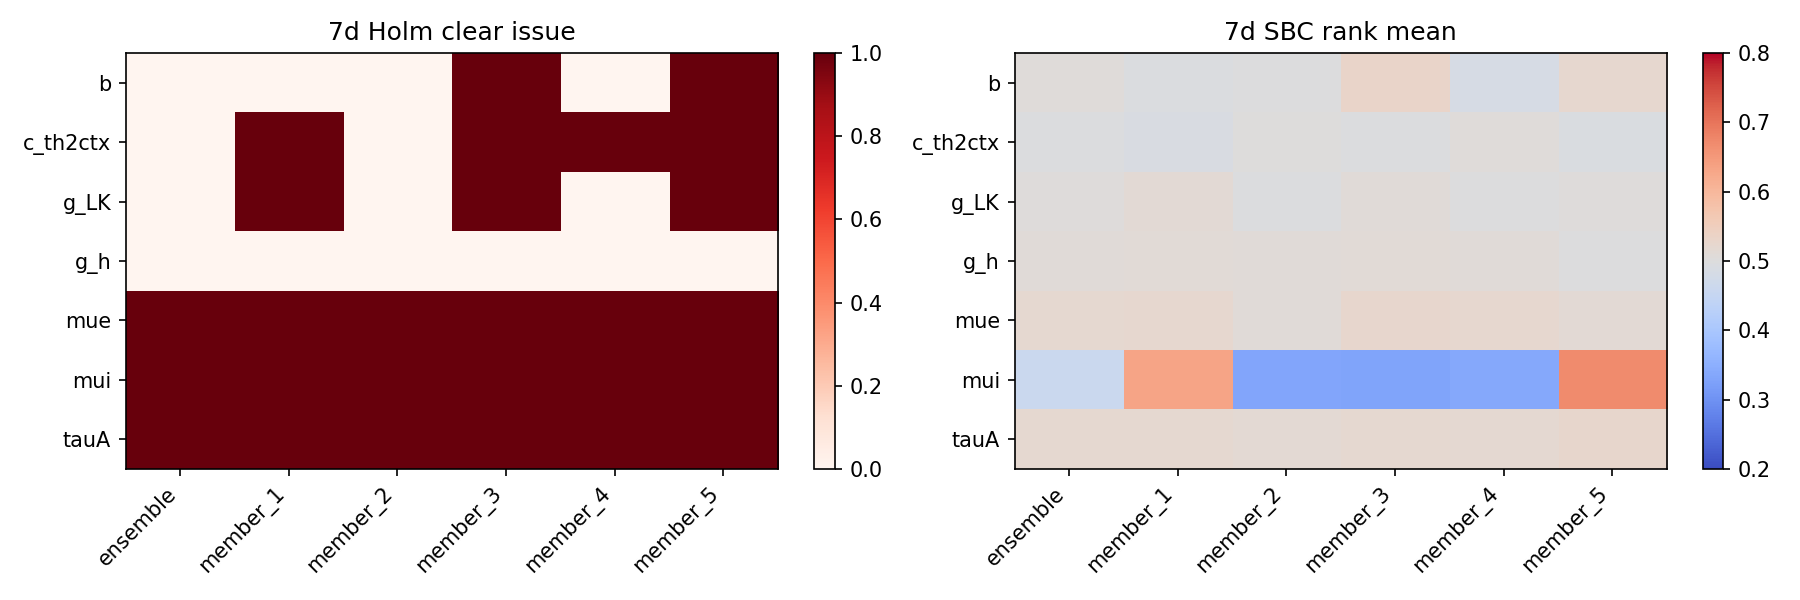

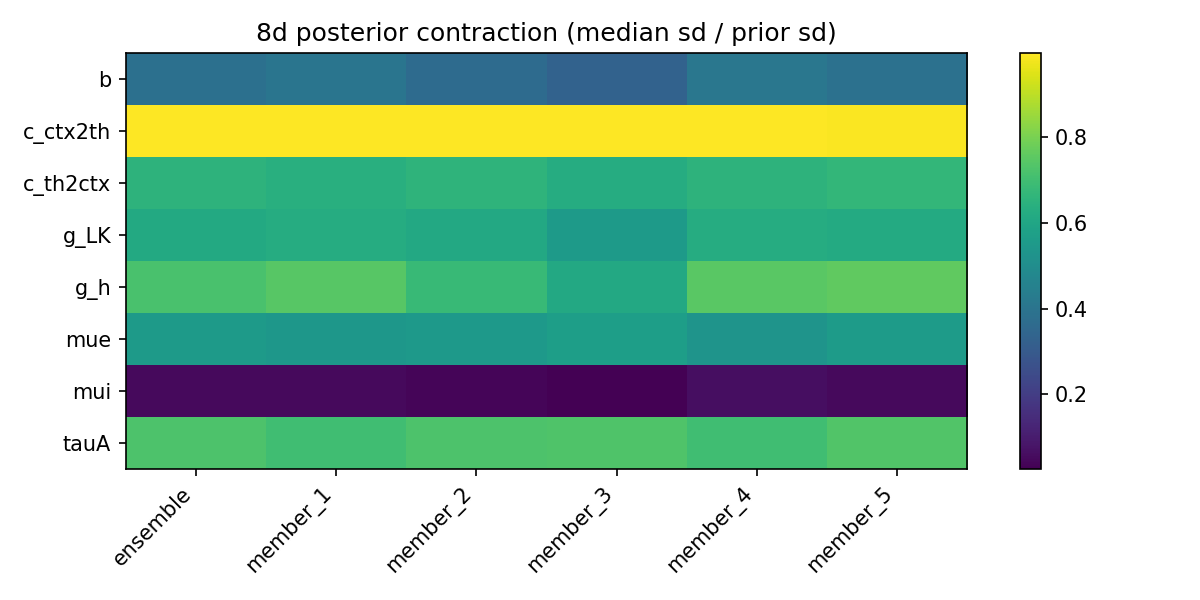

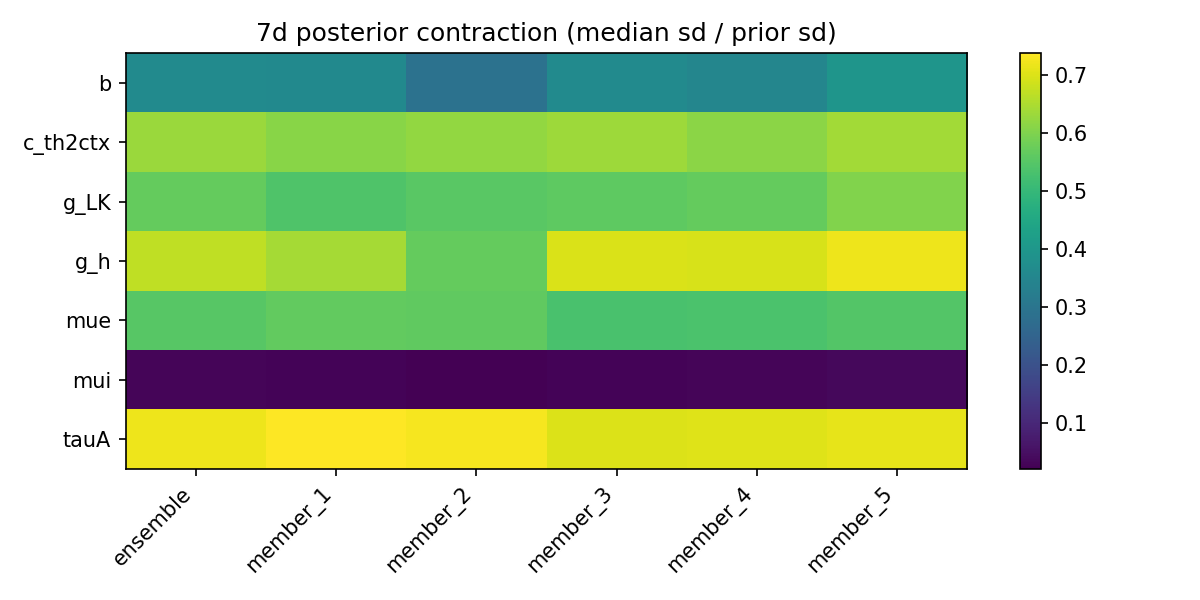

In [5]:
focused = pd.read_csv(N33 / "tables" / "focused_params_mui_mue_tauA.csv")
key = focused[focused.parameter.isin(["mui", "mue", "tauA"])]
display(key[["track", "estimator", "parameter", "rank_mean", "bias_mean", "median_norm_sd", "calibration_slope"]].head(40))
display(Image(filename=str(N33 / "figures" / "marginal_sbc_heatmaps_8d.png")))
display(Image(filename=str(N33 / "figures" / "marginal_sbc_heatmaps_7d.png")))
display(Image(filename=str(N33 / "figures" / "posterior_contraction_heatmap_8d.png")))
display(Image(filename=str(N33 / "figures" / "posterior_contraction_heatmap_7d.png")))

## 8. Location/scale proxy (not mixture variance decomposition)

Stored global `posterior_median` / `posterior_std` summaries are reported only as a
**location/scale proxy**. Formal mixture variance/covariance decomposition uses
member posterior samples (sections 8–9 artifacts).

In [6]:
proxy = pd.read_csv(N33 / "tables" / "location_scale_proxy_global.csv")
display(proxy)

,track,parameter,analysis_name,not_mixture_variance_decomposition,median_across_cases_mean_member_var,median_across_cases_var_of_member_medians,median_ensemble_var_proxy,note
0,8d,mue,location_scale_proxy,True,0.025283,0.000280,0.025514,Uses stored posterior_median/std only; compone...
1,8d,mui,location_scale_proxy,True,0.000227,0.000021,0.000204,Uses stored posterior_median/std only; compone...
2,8d,b,location_scale_proxy,True,0.011890,0.000230,0.012396,Uses stored posterior_median/std only; compone...
3,8d,tauA,location_scale_proxy,True,0.043306,0.000435,0.043908,Uses stored posterior_median/std only; compone...
4,8d,g_LK,location_scale_proxy,True,0.030817,0.000268,0.031682,Uses stored posterior_median/std only; compone...
5,8d,g_h,location_scale_proxy,True,0.042304,0.000545,0.043126,Uses stored posterior_median/std only; compone...
6,8d,c_th2ctx,location_scale_proxy,True,0.035299,0.000404,0.035733,Uses stored posterior_median/std only; compone...
7,8d,c_ctx2th,location_scale_proxy,True,0.082353,0.000502,0.082385,Uses stored posterior_median/std only; compone...
8,7d,mue,location_scale_proxy,True,0.025359,0.000215,0.025388,Uses stored posterior_median/std only; compone...
9,7d,mui,location_scale_proxy,True,0.000107,0.000014,0.000082,Uses stored posterior_median/std only; compone...


## 8–9. Mixture variance / covariance geometry

- Primary \(x_o\) geometry is **illustrative only**.
- Global joint-coverage attribution uses a **pre-frozen** matched subset
  (48 evenly spaced powered cases / track; not selected by joint KS).
- Decomposition uses mixture weights \(w_k=1/K\) (not \(1/(K-1)\)).

<>:8: SyntaxWarning: invalid escape sequence '\('
<>:8: SyntaxWarning: invalid escape sequence '\('
C:\Users\YUS190\AppData\Local\Temp\ipykernel_48220\3015427540.py:8: SyntaxWarning: invalid escape sequence '\('
  display(Markdown("### Primary \(x_o\) illustrative "))


Unit tests pass=True: analytic fro=0.00e+00, MC fro=1.45e-03 (tol=6.47e-02).

### Primary \(x_o\) illustrative 

,track,analysis,parameter,f_between,trace_between_fraction,trace_within,trace_between,trace_mix,pairwise_mahal_mean,n_samples_total,member_counts
0,8d,primary_xo_illustrative_mc_decomp,mue,0.001570,0.007729,0.289443,0.002254,0.291698,0.411236,50000,"[9834, 10100, 9946, 9982, 10138]"
1,8d,primary_xo_illustrative_mc_decomp,mui,0.008047,0.007729,0.289443,0.002254,0.291698,0.411236,50000,"[9834, 10100, 9946, 9982, 10138]"
2,8d,primary_xo_illustrative_mc_decomp,b,0.035385,0.007729,0.289443,0.002254,0.291698,0.411236,50000,"[9834, 10100, 9946, 9982, 10138]"
3,8d,primary_xo_illustrative_mc_decomp,tauA,0.008815,0.007729,0.289443,0.002254,0.291698,0.411236,50000,"[9834, 10100, 9946, 9982, 10138]"
4,8d,primary_xo_illustrative_mc_decomp,g_LK,0.017698,0.007729,0.289443,0.002254,0.291698,0.411236,50000,"[9834, 10100, 9946, 9982, 10138]"
5,8d,primary_xo_illustrative_mc_decomp,g_h,0.001776,0.007729,0.289443,0.002254,0.291698,0.411236,50000,"[9834, 10100, 9946, 9982, 10138]"
6,8d,primary_xo_illustrative_mc_decomp,c_th2ctx,0.003091,0.007729,0.289443,0.002254,0.291698,0.411236,50000,"[9834, 10100, 9946, 9982, 10138]"
7,8d,primary_xo_illustrative_mc_decomp,c_ctx2th,0.000768,0.007729,0.289443,0.002254,0.291698,0.411236,50000,"[9834, 10100, 9946, 9982, 10138]"
8,7d,primary_xo_illustrative_mc_decomp,mue,0.008723,0.021094,0.198665,0.004281,0.202945,0.606945,50000,"[9890, 9998, 10058, 9978, 10076]"
9,7d,primary_xo_illustrative_mc_decomp,mui,0.018115,0.021094,0.198665,0.004281,0.202945,0.606945,50000,"[9890, 9998, 10058, 9978, 10076]"


### Matched-subset geometry (cross-case)

trace_between_fraction                                          \
                       count      mean       std       min       25%   
track                                                                  
7d                      48.0  0.011796  0.007651  0.002135  0.005810   
8d                      48.0  0.008608  0.005057  0.002249  0.004918   

                                    pairwise_mahal_mean                      \
            50%       75%       max               count      mean       std   
track                                                                         
7d     0.009688  0.016362  0.036804                48.0  0.554598  0.141328   
8d     0.008023  0.010886  0.027586                48.0  0.494056  0.124608   

                                                         
            min       25%       50%       75%       max  
track                                                    
7d     0.327129  0.439657  0.544155  0.610589  0.890133  
8d     0.297630  0.417379  0.489066  0.552718  0.860553

**8d**: median trace between fraction=0.0080, median pairwise Mahalanobis=0.489.

**7d**: median trace between fraction=0.0097, median pairwise Mahalanobis=0.544.

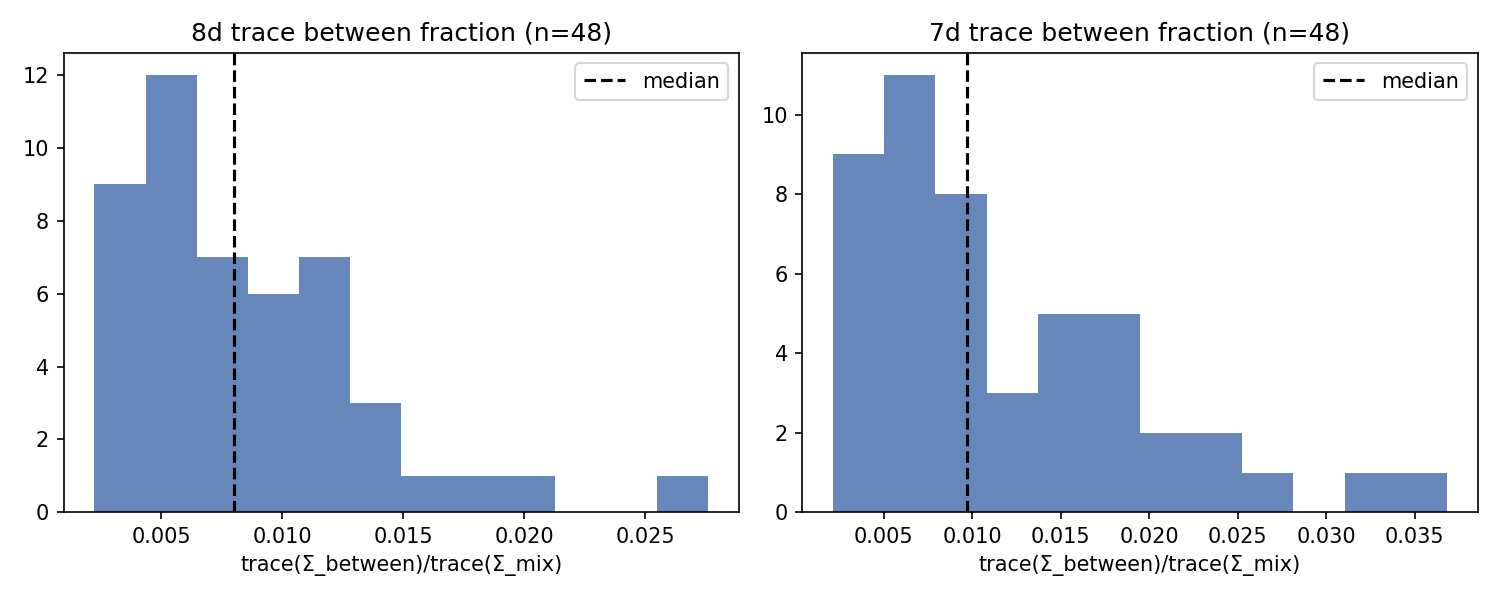

In [7]:
unit = json.loads((N33 / "validation" / "variance_decomposition_unit_test.json").read_text(encoding="utf-8"))
display(Markdown(
    f"Unit tests pass={unit['pass']}: analytic fro={unit['analytic_identity']['frobenius_recon_error']:.2e}, "
    f"MC fro={unit['empirical_mc_sanity']['frobenius_est_vs_emp']:.2e} "
    f"(tol={unit['empirical_mc_sanity']['tolerance']:.2e})."
))
illust = pd.read_csv(N33 / "tables" / "variance_decomposition_primary_illustrative.csv")
display(Markdown("### Primary \(x_o\) illustrative "))
display(illust)
geo = pd.read_csv(N33 / "tables" / "geometry_diagnostics_matched_subset.csv")
display(Markdown("### Matched-subset geometry (cross-case)"))
display(geo.groupby("track")[["trace_between_fraction", "pairwise_mahal_mean"]].describe())
for track in ("8d", "7d"):
    dist = json.loads((N33 / "json" / f"matched_geometry_distribution_{track}.json").read_text(encoding="utf-8"))
    display(Markdown(
        f"**{track}**: median trace between fraction={dist['trace_between_fraction_median']:.4f}, "
        f"median pairwise Mahalanobis={dist['pairwise_mahal_mean_median']:.3f}."
    ))
display(Image(filename=str(N33 / "figures" / "geometry_trace_between_fraction.png")))

## 10. Member-wise PPC status

Phase 2 is executed only by a separate runner. This notebook never starts 2560 simulations.

In [8]:
ppc_status = json.loads((N33 / "json" / "ppc_phase2_status.json").read_text(encoding="utf-8"))
ppc = pd.read_csv(N33 / "tables" / "ppc_by_estimator.csv")
if not ppc_status.get("phase2_complete", False):
    display(Markdown("### PPC pending\nMember-wise PPC has **not** completed. Ensemble reference metrics below are from Notebook 30; ~60% aggregate improvement is an observed reference, not a hard pass/fail cutoff."))
else:
    display(Markdown("### Member-wise PPC available"))
display(ppc)
bench_path = N33 / "json" / "phase2_benchmark_estimate.json"
if bench_path.exists():
    bench = json.loads(bench_path.read_text(encoding="utf-8"))
    display(Markdown(
        f"Benchmark-only estimate for formal 2560 sims: "
        f"~{bench.get('estimated_formal_wall_min')} min "
        f"(does not replace 256/member budget)."
    ))
else:
    display(Markdown("Phase-2 simulator benchmark estimate not yet written."))

### Member-wise PPC available

,track,estimator,status,features_posterior_better,overall_improvement_fraction,bootstrap_improvement_q025,bootstrap_improvement_q975,failure_rate_among_attempts,note
0,8d,ensemble,available_from_notebook30,14,0.600490,NaN,NaN,0.0,"Observed aggregate ~60% is reference only, not..."
1,7d,ensemble,available_from_notebook30,14,0.592818,NaN,NaN,0.0,"Observed aggregate ~60% is reference only, not..."
2,8d,member_1,complete,13,0.533414,0.502875,0.578603,0.0,PPC != calibration; does not offset SBC/joint/...
3,8d,member_2,complete,14,0.617244,0.588398,0.651853,0.0,PPC != calibration; does not offset SBC/joint/...
4,8d,member_3,complete,14,0.642666,0.623987,0.665629,0.0,PPC != calibration; does not offset SBC/joint/...
5,8d,member_4,complete,14,0.583411,0.559077,0.627570,0.0,PPC != calibration; does not offset SBC/joint/...
6,8d,member_5,complete,14,0.621441,0.586432,0.647452,0.0,PPC != calibration; does not offset SBC/joint/...
7,7d,member_1,complete,14,0.594551,0.557066,0.646460,0.0,PPC != calibration; does not offset SBC/joint/...
8,7d,member_2,complete,14,0.612870,0.574761,0.630426,0.0,PPC != calibration; does not offset SBC/joint/...
9,7d,member_3,complete,14,0.600172,0.554558,0.623617,0.0,PPC != calibration; does not offset SBC/joint/...


Benchmark-only estimate for formal 2560 sims: ~55.9565925333235 min (does not replace 256/member budget).

## 11. L-C2ST

Reported `p_value=0` means below permutation-test resolution, not a mathematical exact zero.

,track,estimator,score_observed,null_q95,p_value_display,reject_alpha_0p05
0,8d,ensemble,0.129714,0.024163,< permutation resolution,True
1,8d,member_1,0.169712,0.035377,< permutation resolution,True
2,8d,member_2,0.154405,0.034331,< permutation resolution,True
3,8d,member_3,0.149582,0.038378,< permutation resolution,True
4,8d,member_4,0.177282,0.016021,< permutation resolution,True
5,8d,member_5,0.141439,0.025495,< permutation resolution,True
6,7d,ensemble,0.159474,0.021744,< permutation resolution,True
7,7d,member_1,0.174615,0.030174,< permutation resolution,True
8,7d,member_2,0.104563,0.025416,< permutation resolution,True
9,7d,member_3,0.154209,0.031213,< permutation resolution,True


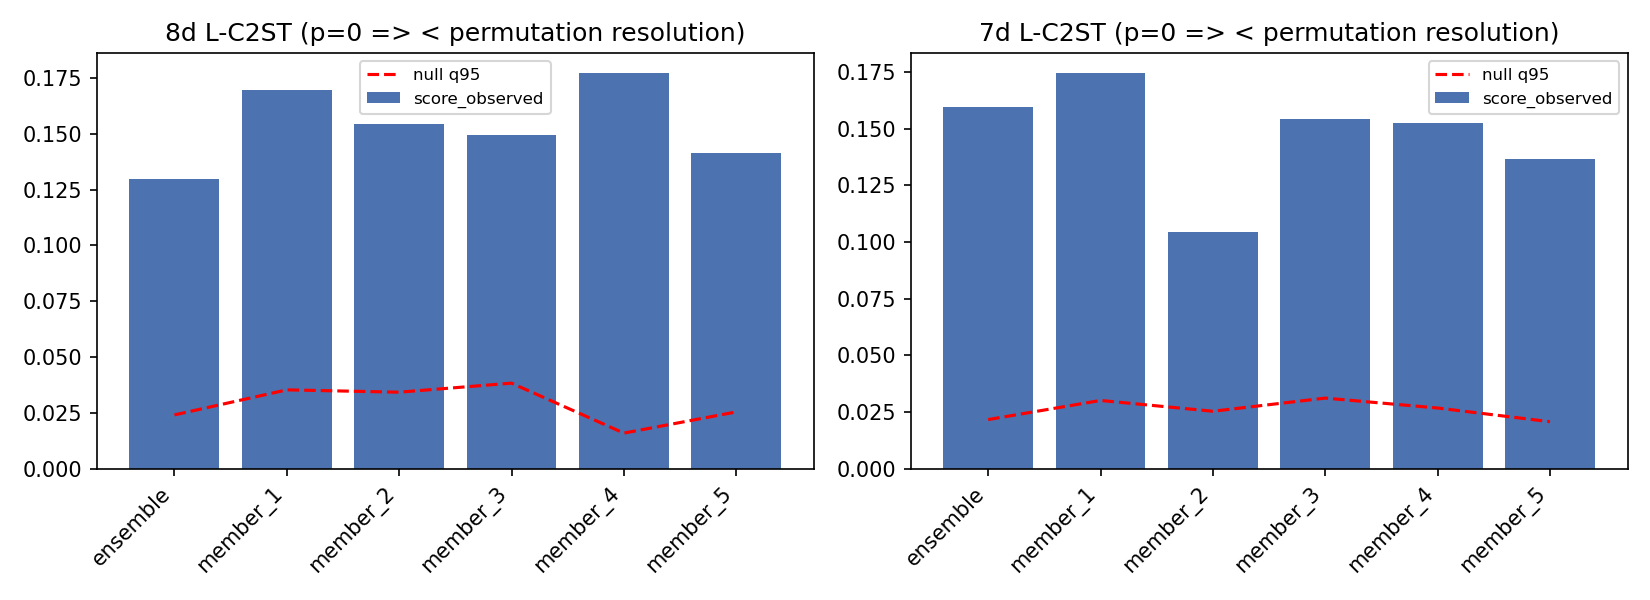

In [9]:
lc2st = pd.read_csv(N33 / "tables" / "lc2st_member_comparison.csv")
display(lc2st[["track", "estimator", "score_observed", "null_q95", "p_value_display", "reject_alpha_0p05"]])
display(Image(filename=str(N33 / "figures" / "lc2st_member_comparison.png")))

## 12–15. Replication, attribution matrix, decision tree, claim card

,track,ensemble_joint_ks,member_joint_ks_median,member_joint_ks_min,member_joint_ks_max,ensemble_over_member_median_ratio
0,8d,0.225012,0.039950,0.028643,0.056158,5.632308
1,7d,0.211778,0.030138,0.019499,0.046158,7.026997


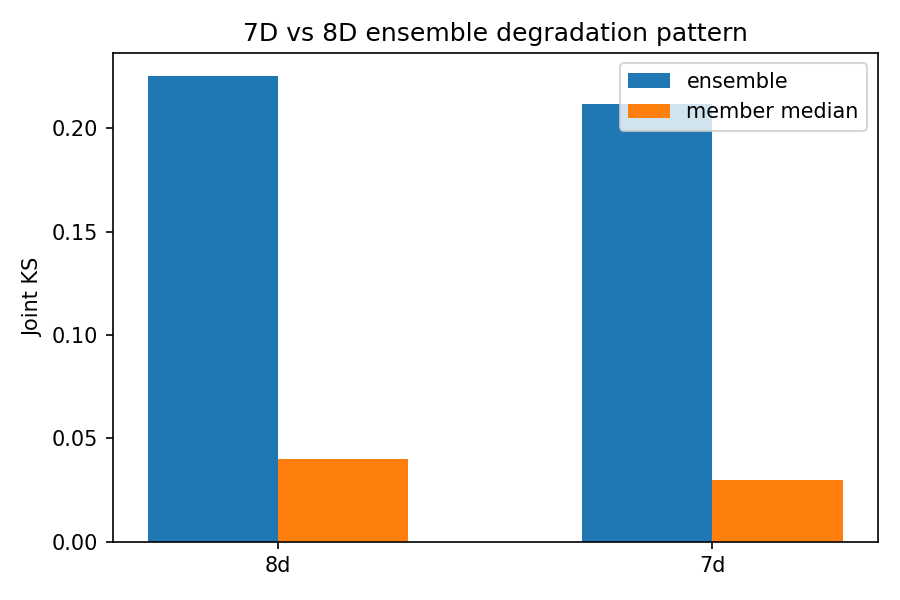

,hypothesis,support,oppose,missing,verdict
0,simulation_count_insufficient,8192 single-member KS worse than 32k members (...,32k individual members already much better joi...,fixed K=5 architecture aggregation scale sweep,evidence_insufficient_confounded
1,equal_weight_ensemble_changes_joint_geometry,ensemble KS >> members; matched-subset geometr...,NaN,aggregation interventions on sealed bank,supported_associational
2,marginal_variance_inflation_causes_joint_failure,NaN,location/scale proxy and primary illustrative ...,none for rejection at marginal level,not_supported_as_sole_explanation
3,few_bad_members_drive_ensemble_degradation,8d mui member_5 rank_mean polarity opposite to...,mui/mue/tauA Holm issues on all members; all L...,sealed-bank robust aggregation study,partial_for_local_polarity_not_global
4,all_estimators_share_calibration_failure,focused SBC holm issues all members=True; L-C2...,PPC ensemble predictive improvement exists (ca...,architecture/summary/boundary probes,supported_for_sbc_lc2st
5,correlation_copula_mismatch,matched-subset corr_diff metrics recorded,NaN,targeted dependence diagnostics,candidate_unverified
6,posterior_mode_overlap_insufficient,pairwise Mahalanobis distances on matched subset,NaN,explicit mode-finding,candidate_unverified
7,c_ctx2th_is_primary_failure_cause,NaN,7d replicates ensemble degradation and SBC iss...,NaN,not_supported
8,mui_boundary_or_recovery_bias,focused table: rank stratification and boundar...,high contraction alone does not establish clas...,summary sensitivity ablation,open_needs_followup
9,mui_summary_sensitivity_insufficient,NaN,NaN,summary ablation experiments,evidence_insufficient


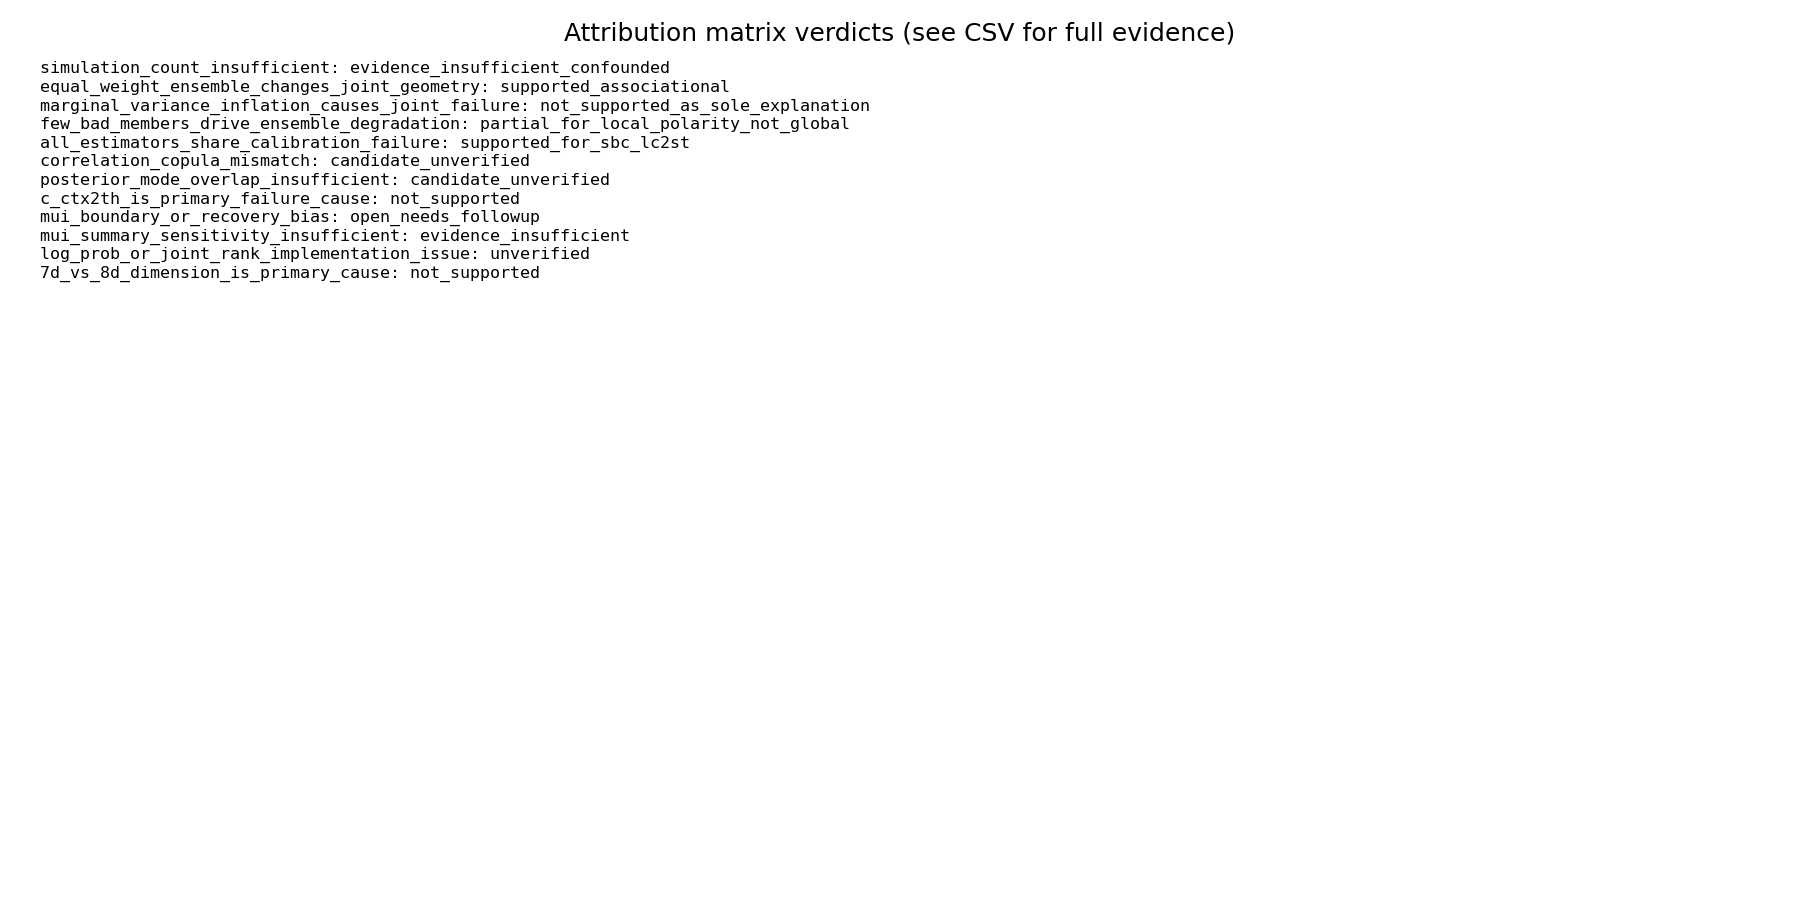

### Provisional two-layer conclusion

**Layer 1.** Equal-weight ensemble is associated with substantially worse joint coverage than individual members and with changes in joint posterior geometry on a pre-frozen matched case subset; marginal variance inflation alone does not fully explain the gap.

**Layer 2.** Individual members still share SBC and L-C2ST calibration failures. Phase-2 member-wise PPC shows predictive improvement versus prior predictive for members, comparable in spirit to the ensemble reference, but PPC must not be read as posterior calibration and does not offset SBC/joint/L-C2ST failures. Selecting one member is not a validated posterior.

### Final claim card

**Supported:** synthetic cortical-rate predictive improvement for ensemble and members (PPC); individual vs ensemble diagnostic comparison on descriptive/sensitivity banks; association between equal-weight ensemble and joint coverage degradation; parameter-specific SBC abnormalities (mui/mue/tauA); 7D/8D failure-pattern replication; matched-subset joint geometry description; member-wise PPC does not remove shared SBC/L-C2ST failures

**Not supported:** real EEG parameter inversion; Fpz-Cz subject-specific physiology; calibrated physiological parameter uncertainty; selecting one member yields a trusted posterior; c_ctx2th proven structural non-identifiability; mui proven classical overconfidence; 131k/1M guaranteed fix; logsumexp/density dilution proven root cause; powered_1024 as untouched final evaluation; PPC pass as calibration pass

In [10]:
rep = pd.read_csv(N33 / "tables" / "track_replication_summary.csv")
matrix = pd.read_csv(N33 / "tables" / "attribution_matrix.csv")
decision = json.loads((N33 / "json" / "provisional_decision_tree.json").read_text(encoding="utf-8"))
claim = json.loads((N33 / "json" / "final_claim_card.json").read_text(encoding="utf-8"))
display(rep)
display(Image(filename=str(N33 / "figures" / "7d_vs_8d_attribution.png")))
display(matrix)
display(Image(filename=str(N33 / "figures" / "attribution_matrix.png")))
display(Markdown("### Provisional two-layer conclusion"))
for layer in decision["layers"]:
    display(Markdown(f"**Layer {layer['layer']}.** {layer['claim']}"))
display(Markdown("### Final claim card"))
display(Markdown("**Supported:** " + "; ".join(claim["supported"])))
display(Markdown("**Not supported:** " + "; ".join(claim["not_supported"])))